# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [10]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv('/Users/matthewcorning/Downloads/archive/track_data_final.csv')



data.head()

In [11]:
data.head()

,track_id,track_name,track_number,track_popularity,track_duration_ms,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type
0,6pymOcrCnMuCWdgGVTvUgP,3,57,61,213173,False,Britney Spears,80.0,17755451.0,['pop'],325wcm5wMnlfjmKZ8PXIIn,The Singles Collection,2009-11-09,58,compilation
1,2lWc1iJlz2NVcStV5fbtPG,Clouds,1,67,158760,False,BUNT.,69.0,293734.0,['stutter house'],2ArRQNLxf9t0O0gvmG5Vsj,Clouds,2023-01-13,1,single
2,1msEuwSBneBKpVCZQcFTsU,Forever & Always (Taylor’s Version),11,63,225328,False,Taylor Swift,100.0,145396321.0,[],4hDok0OAJd57SGIT8xuWJH,Fearless (Taylor's Version),2021-04-09,26,album
3,7bcy34fBT2ap1L4bfPsl9q,I Didn't Change My Number,2,72,158463,True,Billie Eilish,90.0,118692183.0,[],0JGOiO34nwfUdDrD612dOp,Happier Than Ever,2021-07-30,16,album
4,0GLfodYacy3BJE7AI3A8en,Man Down,7,57,267013,False,Rihanna,90.0,68997177.0,[],5QG3tjE5L9F6O2vCAPph38,Loud,2010-01-01,13,album


In [12]:
unique_counts = data.groupby('track_name')['track_id'].nunique()

#understand tracks with multiple ids
duplicates = unique_counts[unique_counts > 1]
print(duplicates)

track_name
&burn (with Vince Staples)    2
12 to 12                      2
2002                          2
22                            5
23                            3
                             ..
willow                        3
yes, and?                     2
you broke me first            2
your favorite dress           2
Échame La Culpa               3
Name: track_id, Length: 941, dtype: int64


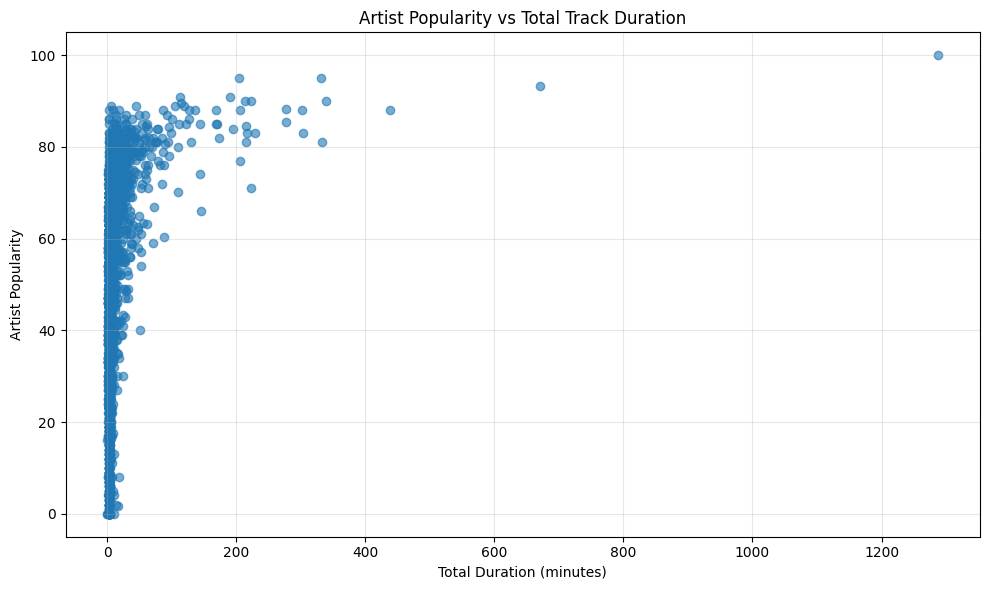

In [23]:
# Step 1: Remove duplicate track_ids
data_cleaned = data.drop_duplicates(subset='track_id')

# Step 2: Group by artist and aggregate
artist_data = data_cleaned.groupby('artist_name').agg({
    'track_duration_ms': 'sum',
    'artist_popularity': 'mean'
}).reset_index()

# Step 3: Convert ms to minutes
artist_data['duration_minutes'] = artist_data['track_duration_ms'] / (1000 * 60)

# Step 4: Create the scatter plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(artist_data['duration_minutes'], artist_data['artist_popularity'], alpha=0.6)
plt.xlabel('Total Duration (minutes)')
plt.ylabel('Artist Popularity')
plt.title('Artist Popularity vs Total Track Duration')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
artist_date = data.groupby('artist_name')['track_id'].nunique()

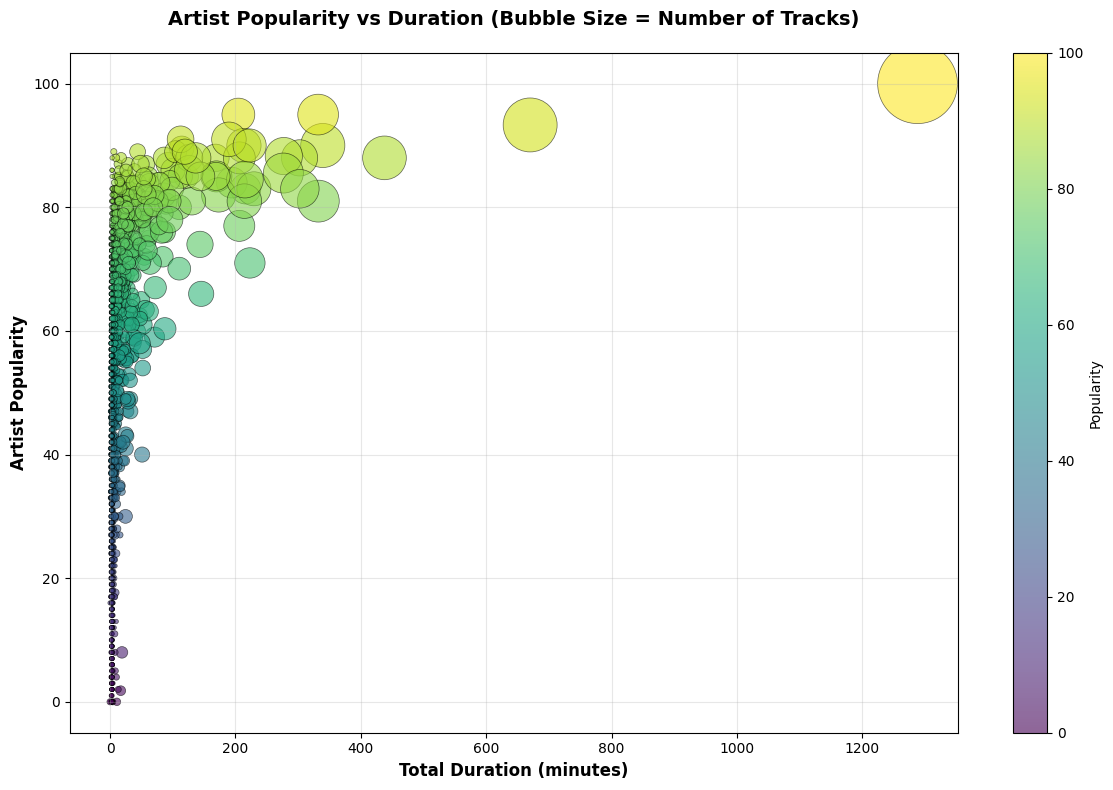

In [24]:
# First calculate number of tracks per artist
artist_data['num_tracks'] = data_cleaned.groupby('artist_name')['track_id'].count().values

fig, ax = plt.subplots(figsize=(12, 8))

# Create bubble chart
scatter = ax.scatter(artist_data['duration_minutes'],
                     artist_data['artist_popularity'],
                     s=artist_data['num_tracks']*10,  # Bubble size
                     c=artist_data['artist_popularity'],  # Color by popularity
                     cmap='viridis',
                     alpha=0.6,
                     edgecolors='black',
                     linewidths=0.5)

# Colorbar
plt.colorbar(scatter, label='Popularity')

ax.set_xlabel('Total Duration (minutes)', fontsize=12, fontweight='bold')
ax.set_ylabel('Artist Popularity', fontsize=12, fontweight='bold')
ax.set_title('Artist Popularity vs Duration (Bubble Size = Number of Tracks)',
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

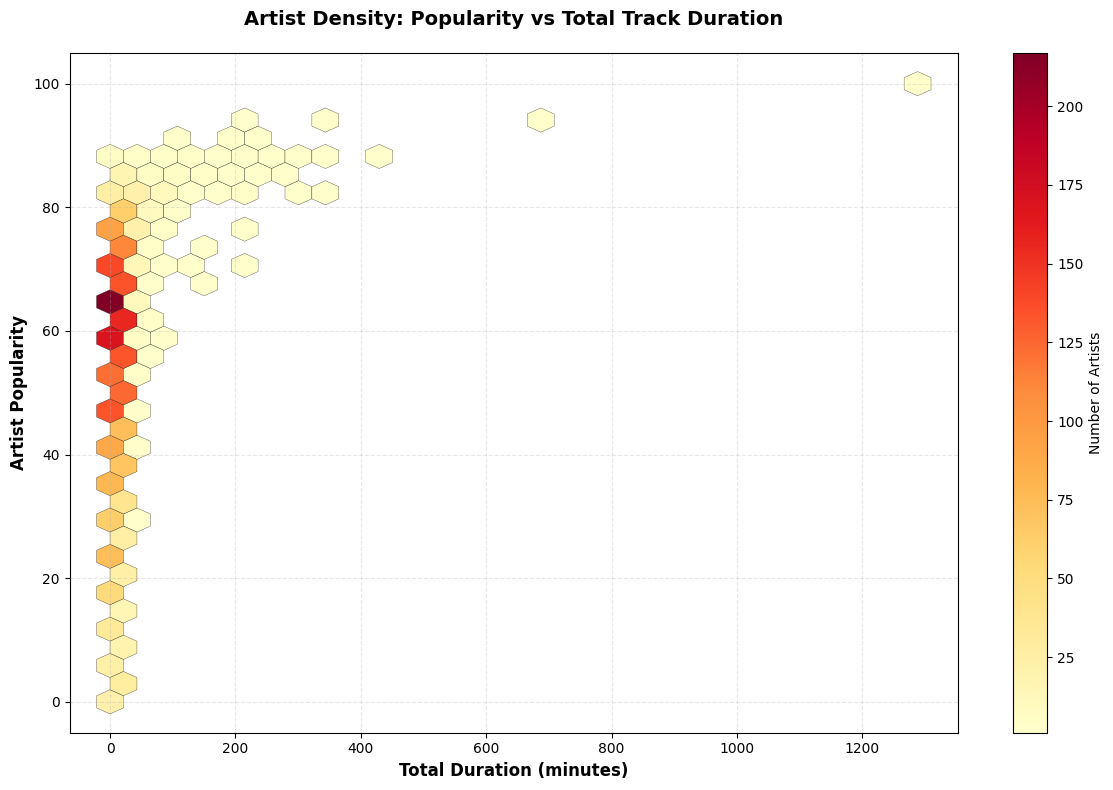

In [25]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 8))

# Create hexbin plot (shows density of artists)
hexbin = ax.hexbin(artist_data['duration_minutes'],
                    artist_data['artist_popularity'],
                    gridsize=30,
                    cmap='YlOrRd',
                    mincnt=1,
                    edgecolors='black',
                    linewidths=0.2)

# Add colorbar
cb = plt.colorbar(hexbin, ax=ax, label='Number of Artists')

# Labels and title
ax.set_xlabel('Total Duration (minutes)', fontsize=12, fontweight='bold')
ax.set_ylabel('Artist Popularity', fontsize=12, fontweight='bold')
ax.set_title('Artist Density: Popularity vs Total Track Duration',
             fontsize=14, fontweight='bold', pad=20)

# Add grid
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

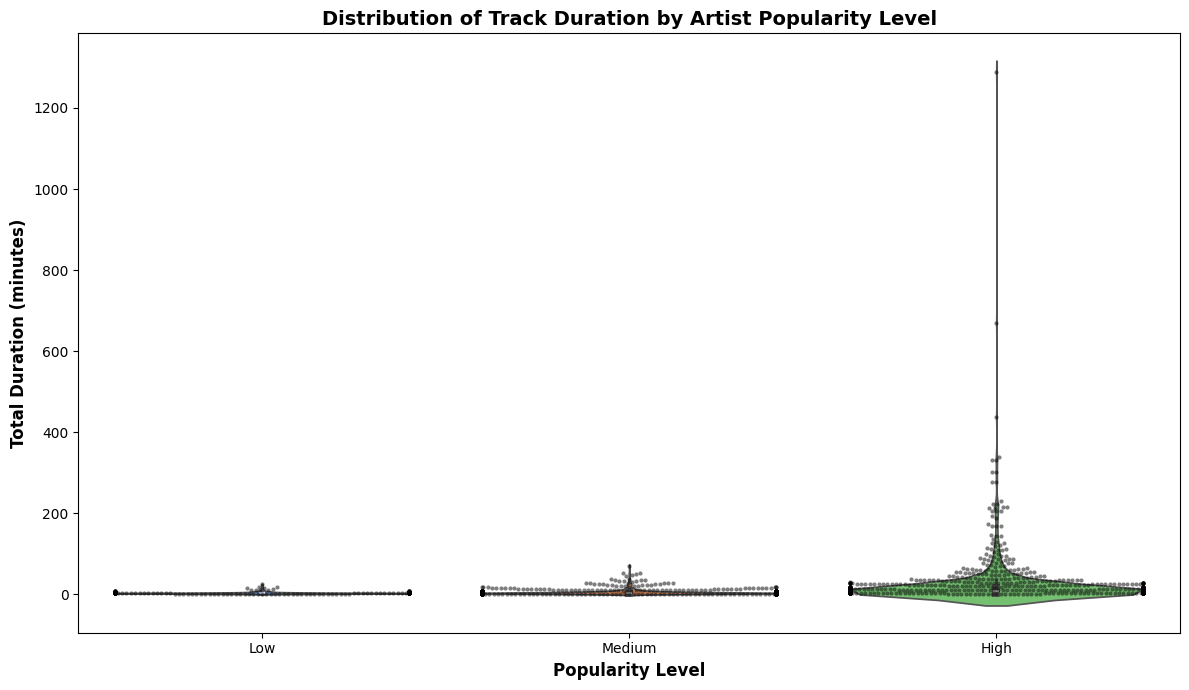

In [28]:
import seaborn as sns

# Create popularity bins
artist_data['popularity_bin'] = pd.cut(artist_data['artist_popularity'],
                                        bins=[0, 30, 60, 100],
                                        labels=['Low', 'Medium', 'High'])

fig, ax = plt.subplots(figsize=(12, 7))
sns.violinplot(data=artist_data, x='popularity_bin', y='duration_minutes',
               palette='muted', ax=ax)
sns.swarmplot(data=artist_data, x='popularity_bin', y='duration_minutes',
              color='black', alpha=0.5, size=3, ax=ax)

ax.set_xlabel('Popularity Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Duration (minutes)', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Track Duration by Artist Popularity Level',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

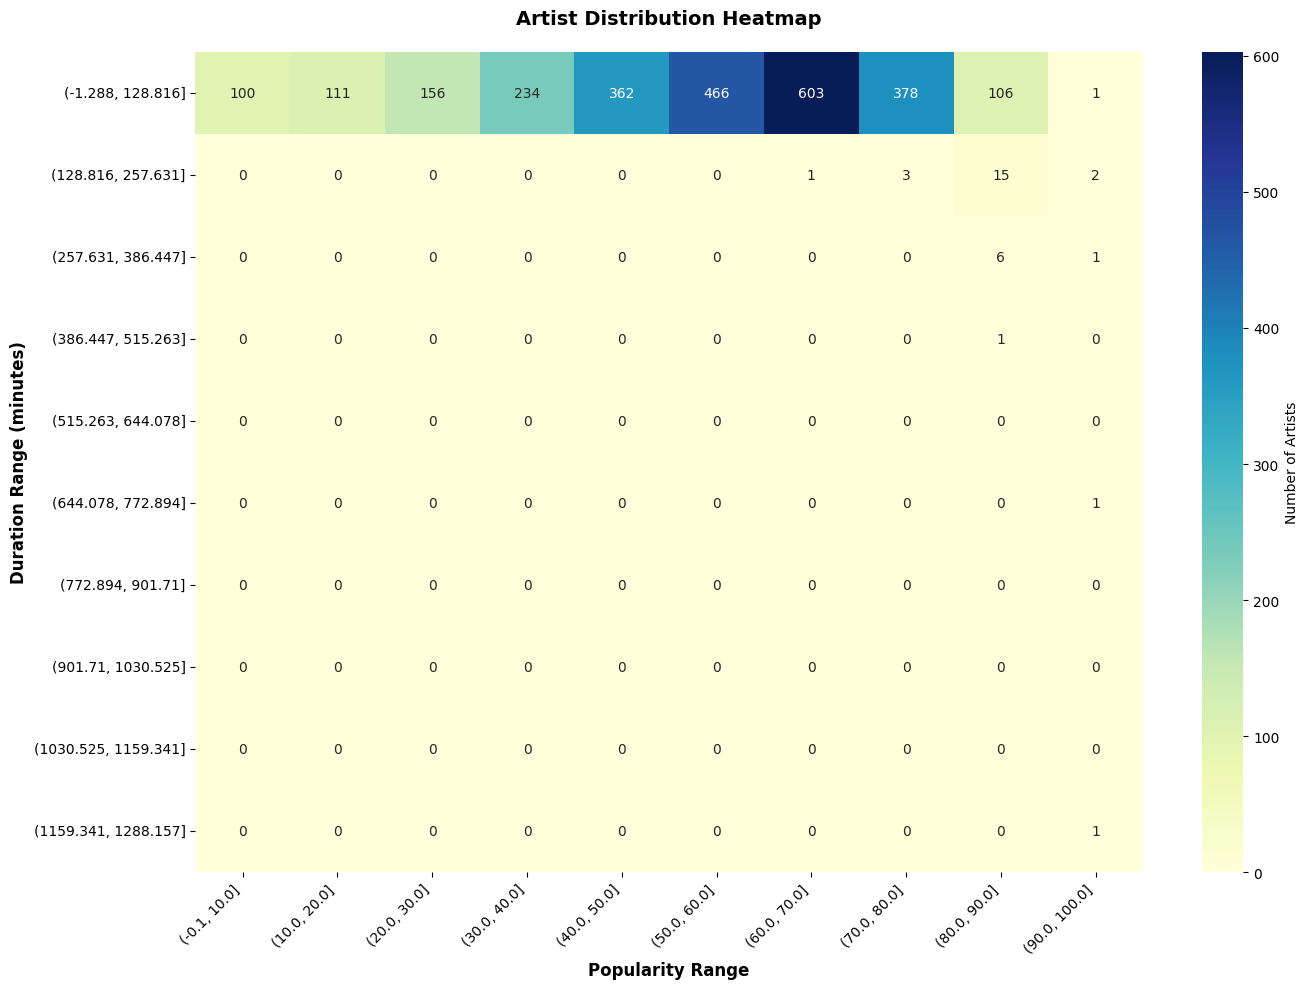

In [29]:
# Create bins for both axes
artist_data['duration_category'] = pd.cut(artist_data['duration_minutes'], bins=10)
artist_data['popularity_category'] = pd.cut(artist_data['artist_popularity'], bins=10)

# Create heatmap data
heatmap_data = artist_data.groupby(['duration_category', 'popularity_category']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=True, fmt='d',
            cbar_kws={'label': 'Number of Artists'}, ax=ax)

ax.set_xlabel('Popularity Range', fontsize=12, fontweight='bold')
ax.set_ylabel('Duration Range (minutes)', fontsize=12, fontweight='bold')
ax.set_title('Artist Distribution Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()